# Fitting Delta Function with Burst Model

In [1]:
import os
import math
import numpy as np
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


In [2]:
z = 2

import os
import math
import numpy as np
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

In [3]:
os.environ["PATH"] += r";C:\Users\Abigail Crowther\AppData\Local\Programs\MiKTeX\miktex\bin\x64" 

mpl.rcParams.update({ "text.usetex": True, "font.family": "serif", "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}" }) 

os.chdir(r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Code")

In [4]:
filter_folder = r"D:\Users\Abigail Crowther\Desktop\Uni\Year 4\MPhys Projects\Semester 2 - Star Formation Histories\star-formation-histories\Data\starburst_filters"

filter_files = sorted([
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
])

global_min = np.inf
global_max = -np.inf

for ffile in filter_files:
    data = np.loadtxt(ffile)
    global_min = min(global_min, data[:,0].min())
    global_max = max(global_max, data[:,0].max())

print(f"Wavelength coverage: {global_min:.0f}–{global_max:.0f} Å")

Wavelength coverage: 3526–50996 Å


In [5]:
from astropy.cosmology import Planck18
import numpy as np

# age of universe at this redshift (in Gyr)
age_universe = Planck18.age(z).value

print(f"Age of Universe at z={z}: {age_universe:.3f} Gyr")

# original ages
ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200,1100,100)
years = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

# enforce physical limit
years = years[years <= age_universe]

print("Valid ages:", years)

dust = {
    "type": "Calzetti",
    "Av": 0.2,
    "eta": 2.
}

nebular = {
    "logU": -3.
}

Age of Universe at z=2: 3.277 Gyr
Valid ages: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.2  0.3  0.4
 0.5  0.6  0.7  0.8  0.9  1.  ]


In [7]:
dt = np.diff(years)
print("Time step range:", dt.min(), dt.max())

Time step range: 0.009999999999999995 0.10000000000000009


In [6]:
def burst_model(t, z, dust, nebular):
    return {
        "redshift": z,
        "burst": {"age": t, "massformed": 10, "metallicity": 0.5},
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }


def compute_filter_wavelengths(filter_files):
    eff_waves = []
    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:, 0]
        transmission = filt_data[:, 1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        eff_waves.append(eff_wave)
    return np.array(eff_waves)


def build_models(years, z, dust, nebular, filter_files, wavelength_range):

    models = []

    for t in years:
        components = burst_model(t, z, dust, nebular)

        model = pipes.model_galaxy(
            components,
            filt_list=filter_files,
            spec_wavs=wavelength_range
        )

        models.append(model)

    return models

In [7]:
wavelength_range = np.arange(
    global_min - 500,
    global_max + 500,
    5.
)

filter_wavelengths = compute_filter_wavelengths(filter_files)

models = build_models(
    years,
    z,
    dust,
    nebular,
    filter_files,
    wavelength_range
)

In [8]:
SNR = 10

synthetic_flux = np.array([model.photometry for model in models])  # F_lambda

c = 2.99792458e18  # Å/s

flux_nu = synthetic_flux * (filter_wavelengths**2) / c
flux_nu = flux_nu / 1e-23      # Jy
flux_in_microjansky = flux_nu * 1e6

err_in_microjansky = flux_in_microjansky / SNR

In [9]:
galaxy_values = []

for age in years:

    age_idx = np.argmin(np.abs(years - age))

    print(f"Fitting model with age = {years[age_idx]:.3f} Gyr")

    galaxy_photometry = np.c_[
        flux_in_microjansky[age_idx],
        err_in_microjansky[age_idx]
    ]

    galaxy = pipes.galaxy(
        str(years[age_idx]),
        lambda ID: galaxy_photometry,
        spectrum_exists=False,
        filt_list=filter_files
    )

    galaxy_values.append(galaxy)

Fitting model with age = 0.000 Gyr
Fitting model with age = 0.010 Gyr
Fitting model with age = 0.020 Gyr
Fitting model with age = 0.030 Gyr
Fitting model with age = 0.040 Gyr
Fitting model with age = 0.050 Gyr
Fitting model with age = 0.060 Gyr
Fitting model with age = 0.070 Gyr
Fitting model with age = 0.080 Gyr
Fitting model with age = 0.090 Gyr
Fitting model with age = 0.100 Gyr
Fitting model with age = 0.200 Gyr
Fitting model with age = 0.300 Gyr
Fitting model with age = 0.400 Gyr
Fitting model with age = 0.500 Gyr
Fitting model with age = 0.600 Gyr


## Fitting

In [ ]:
burst_age = 1.0
burst_sigma = 0.02
burst_amplitude = 10.0

burst = burst_amplitude * np.exp(-0.5 * ((years - burst_age) / burst_sigma)**2)

custom = {
    "history": burst
}

# Dust
dust_fit = {
    "type": "Calzetti",
    "Av": (0., 2.)
}

# Fit instructions
fit_instructions = {
    "redshift": z,
    "burst": burst,
    "dust": dust_fit,
    "nebular": {"logU": (-4., -2.)}
}

In [11]:
fits = []

for i, galaxy in enumerate(galaxy_values):

    print(f"Running fit {i+1}/{len(galaxy_values)}  (Age = {years[i]:.3f} Gyr)")

    fit = pipes.fit(galaxy, fit_instructions)
    fit.fit(verbose=True)

    fits.append(fit)

print("All fits finished.")

Running fit 1/16  (Age = 0.000 Gyr)
MultiNest not available. Switching to nautilus.

Bagpipes: fitting object 0.0

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


Finished  | 51     | 1        | 4        | 28100    | N/A    | 4738  | +680.85  

Completed in 393.0 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
burst:age                      0.007      0.008      0.008
burst:massformed              10.496     10.518     10.540
burst:metallicity              0.118      0.127      0.138
dust:Av                        0.563      0.586      0.610
nebular:logU                  -3.954     -3.898     -3.831


Running fit 2/16  (Age = 0.010 Gyr)
MultiNest not available. Switching to nautilus.

Bagpipes: fitting object 0.01

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 29     | 1        | 4        | 17000    | N/A    | 2754  | +757.62  

Completed in 224.4 seconds.

Parameter          


Plotting results for age 0.000 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-19 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

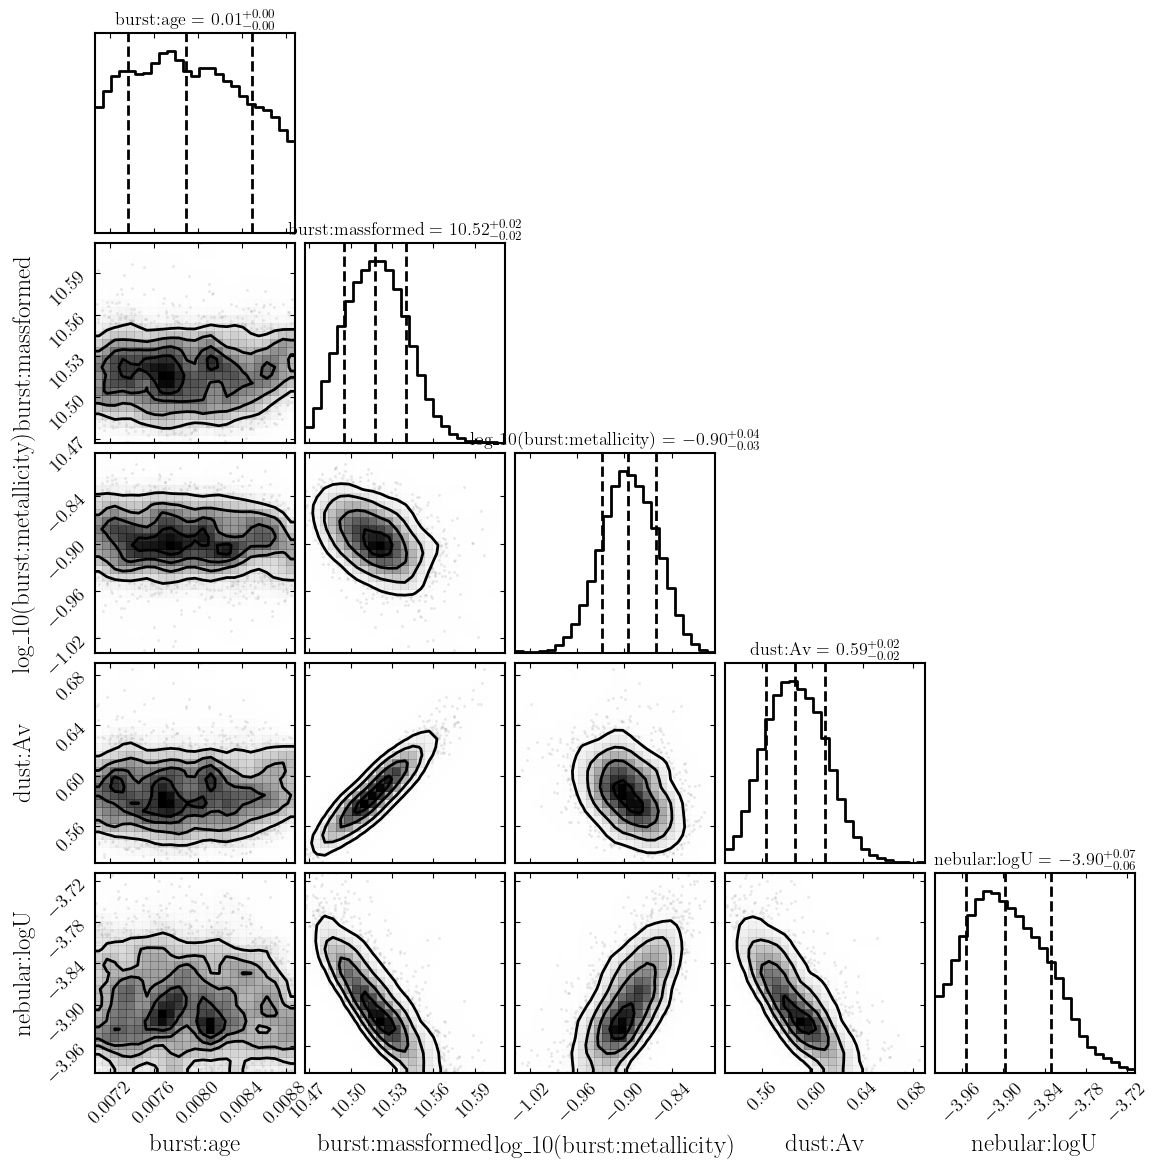


Plotting results for age 0.010 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-19 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

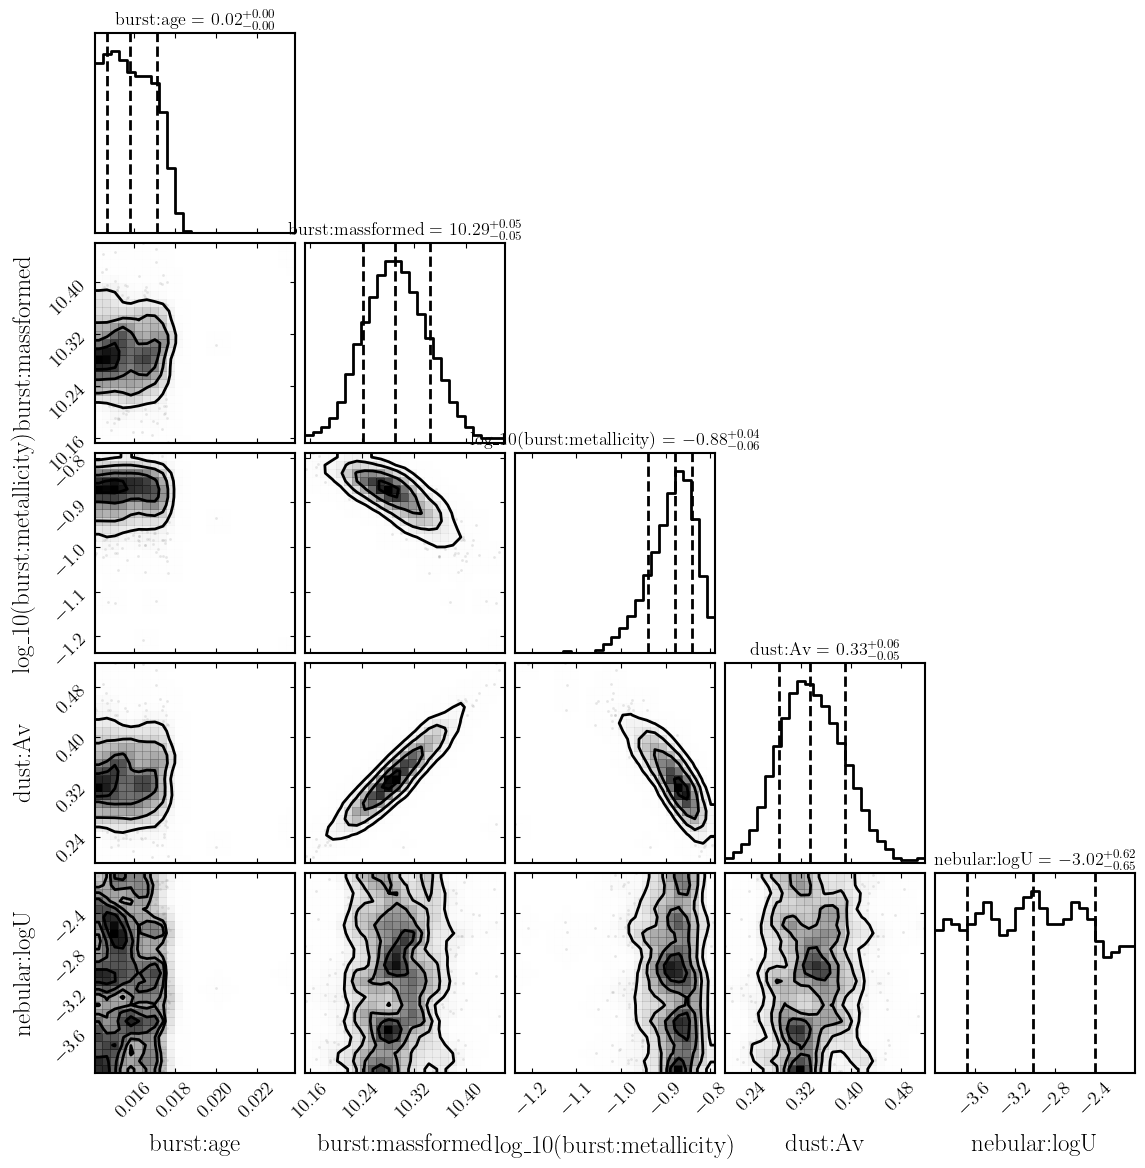


Plotting results for age 0.020 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-19 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

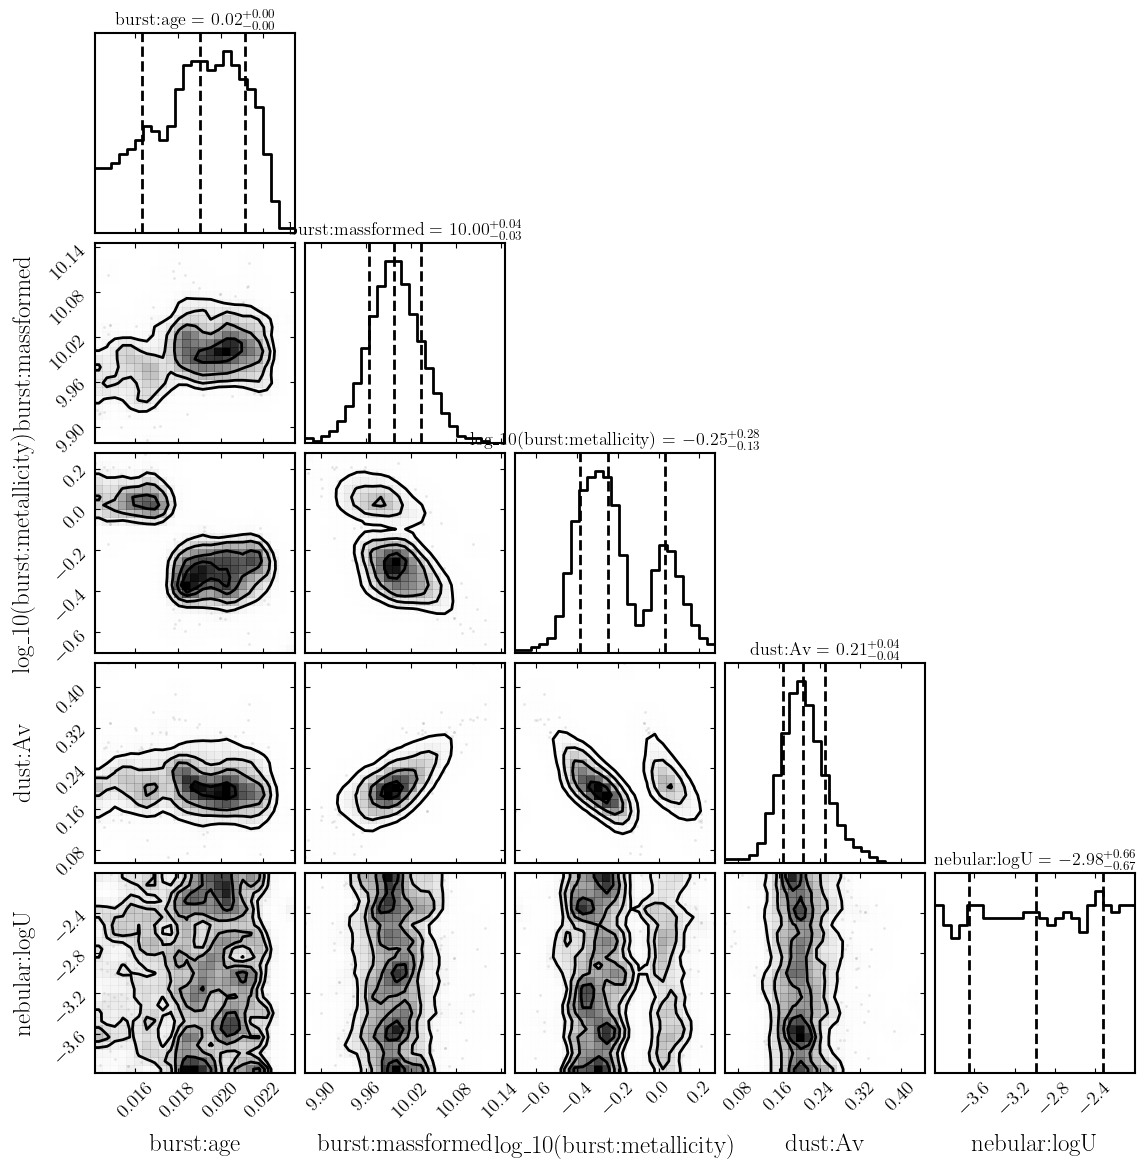


Plotting results for age 0.030 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-19 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

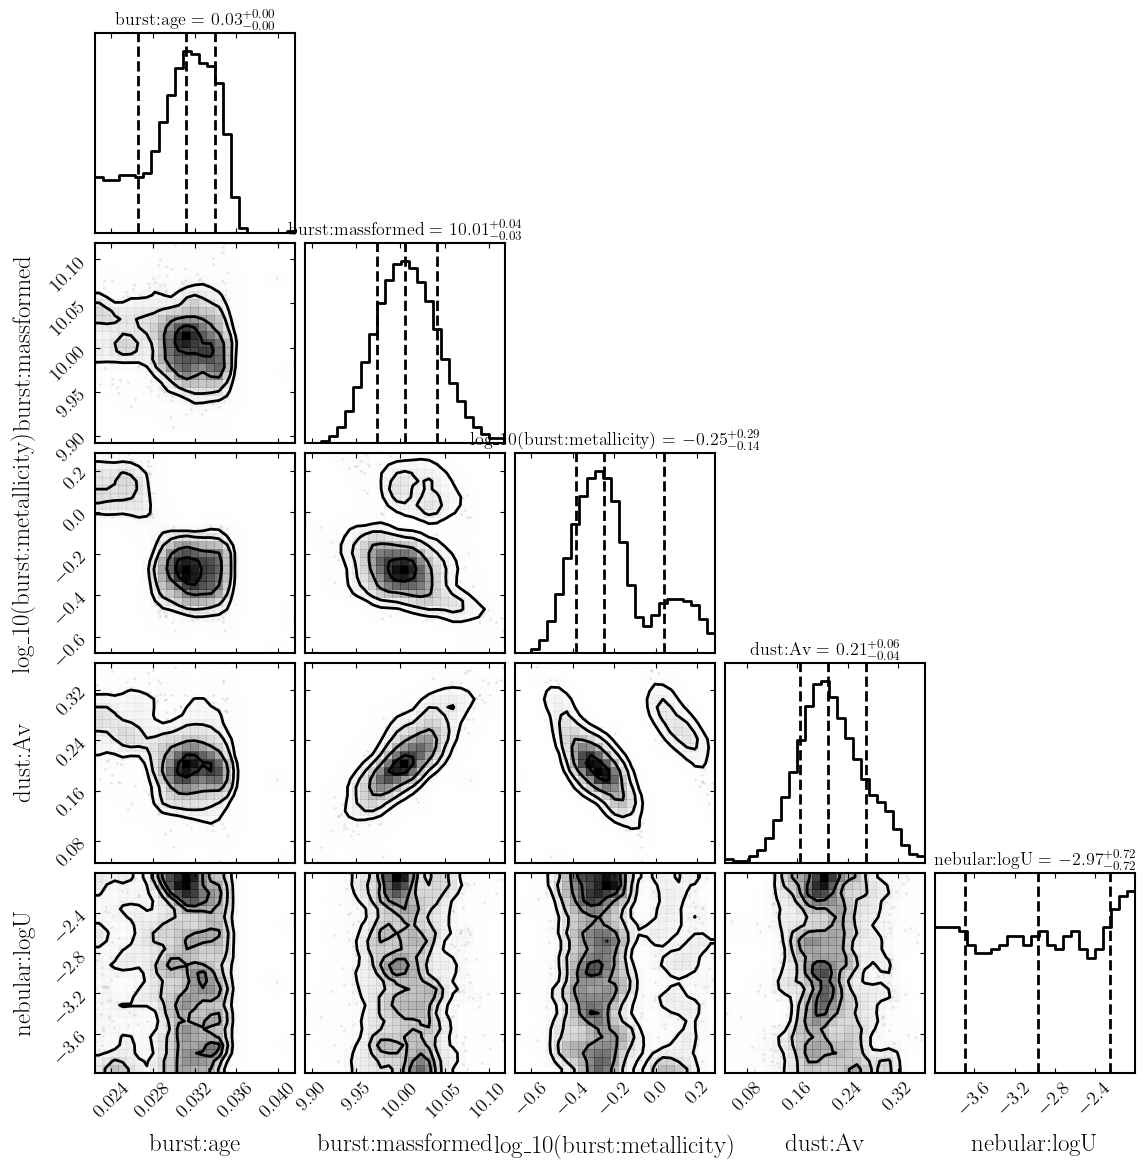


Plotting results for age 0.040 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-20 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

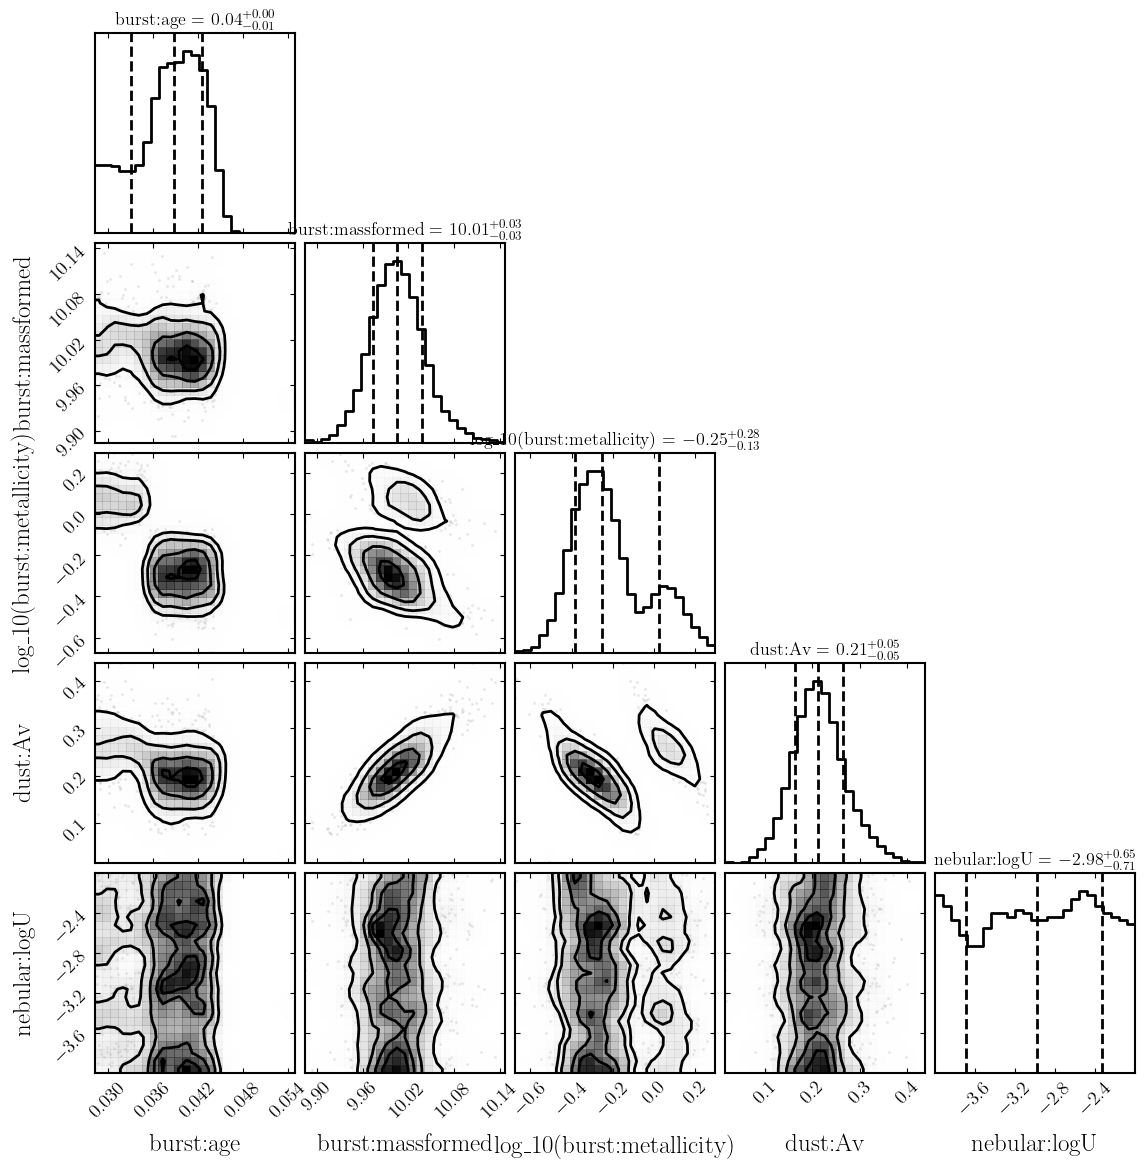


Plotting results for age 0.050 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-20 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

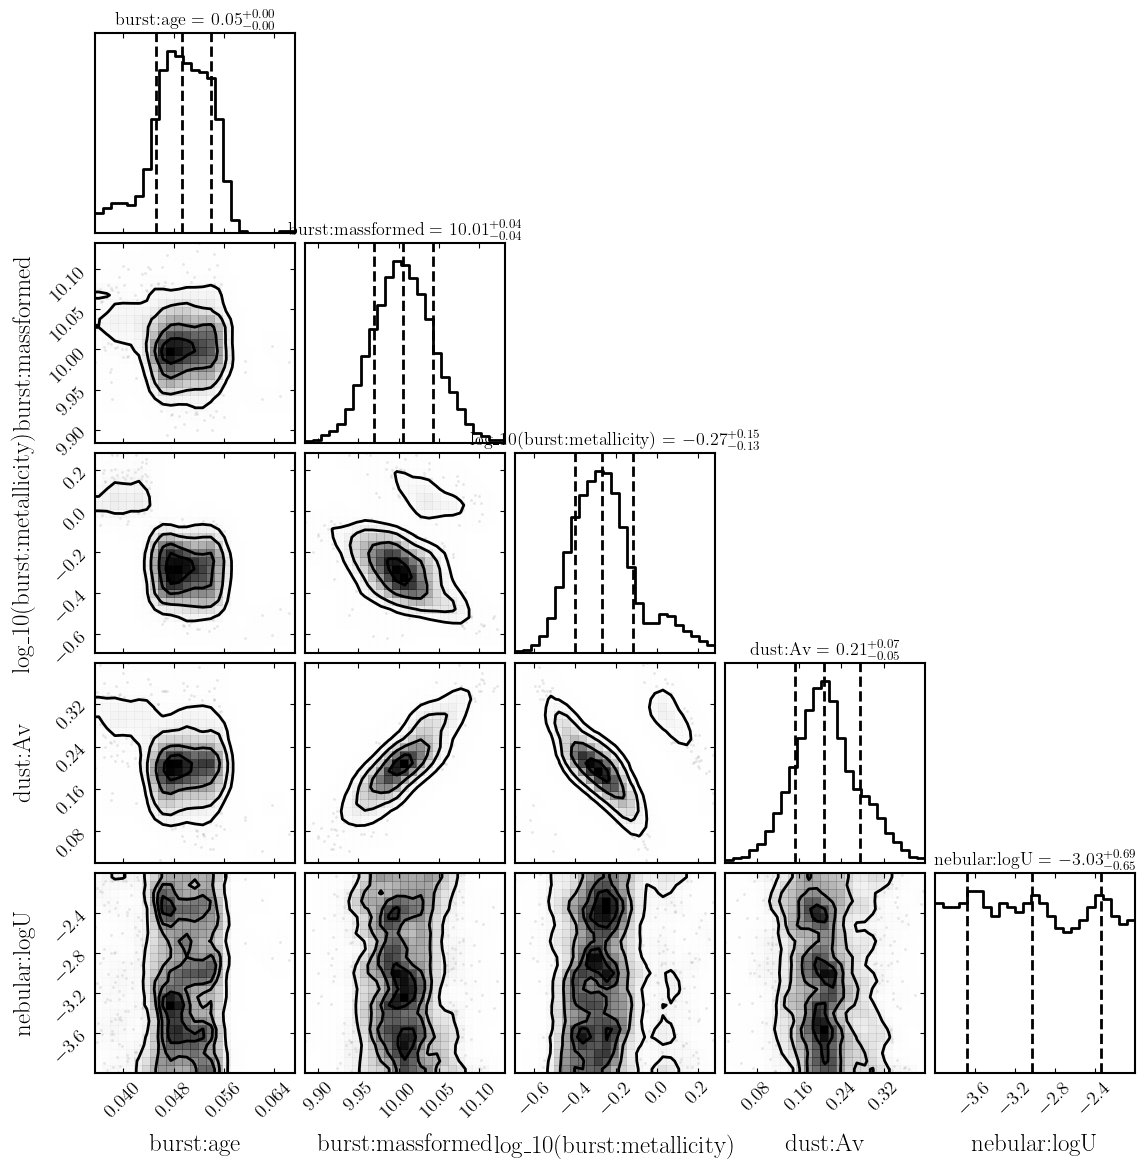


Plotting results for age 0.060 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-20 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

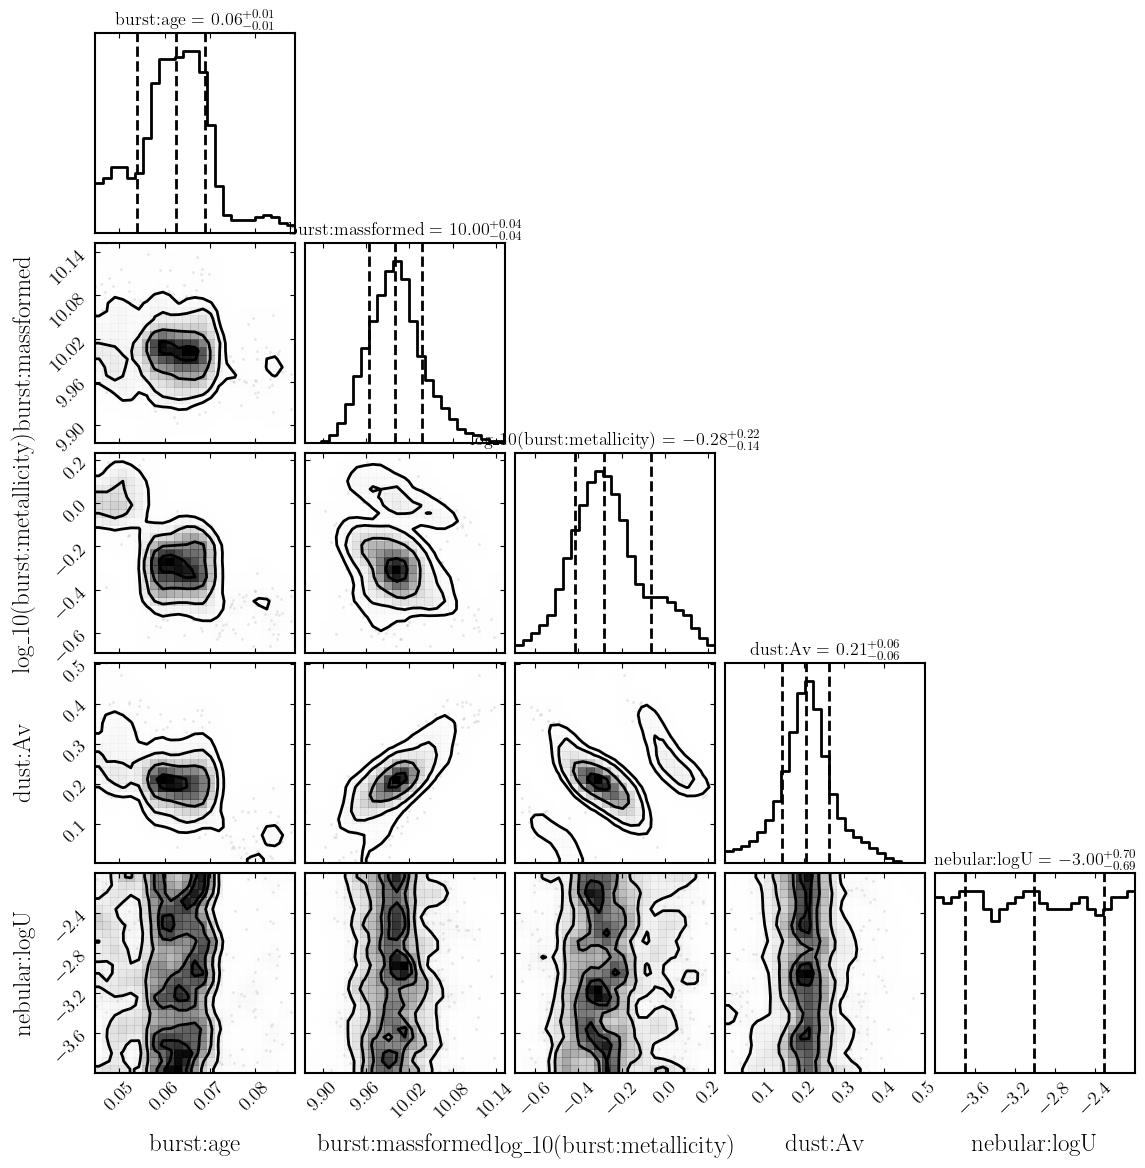


Plotting results for age 0.070 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-20 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

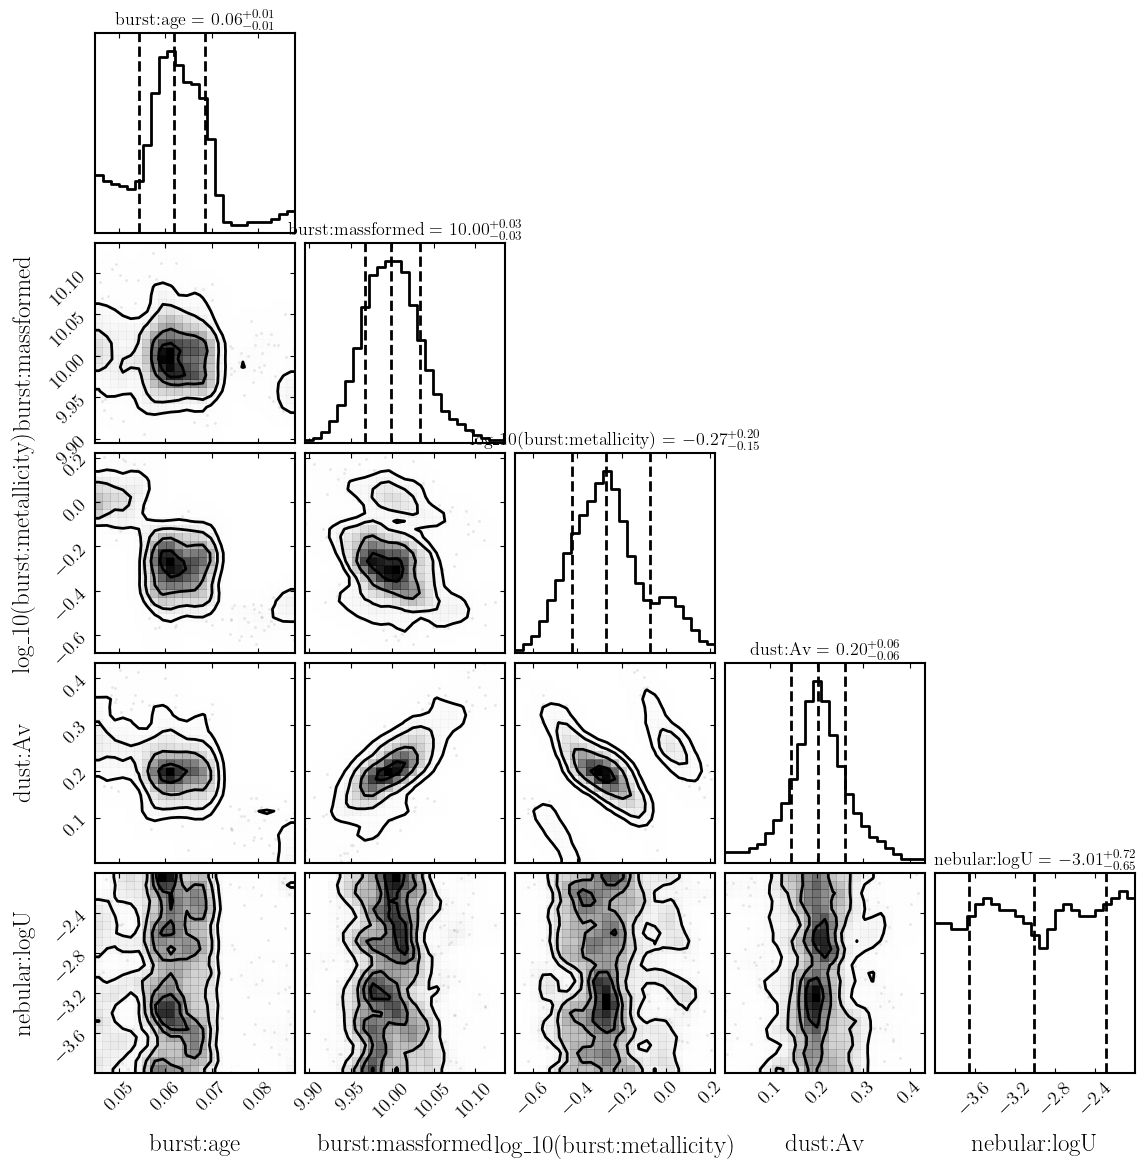


Plotting results for age 0.080 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-20 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

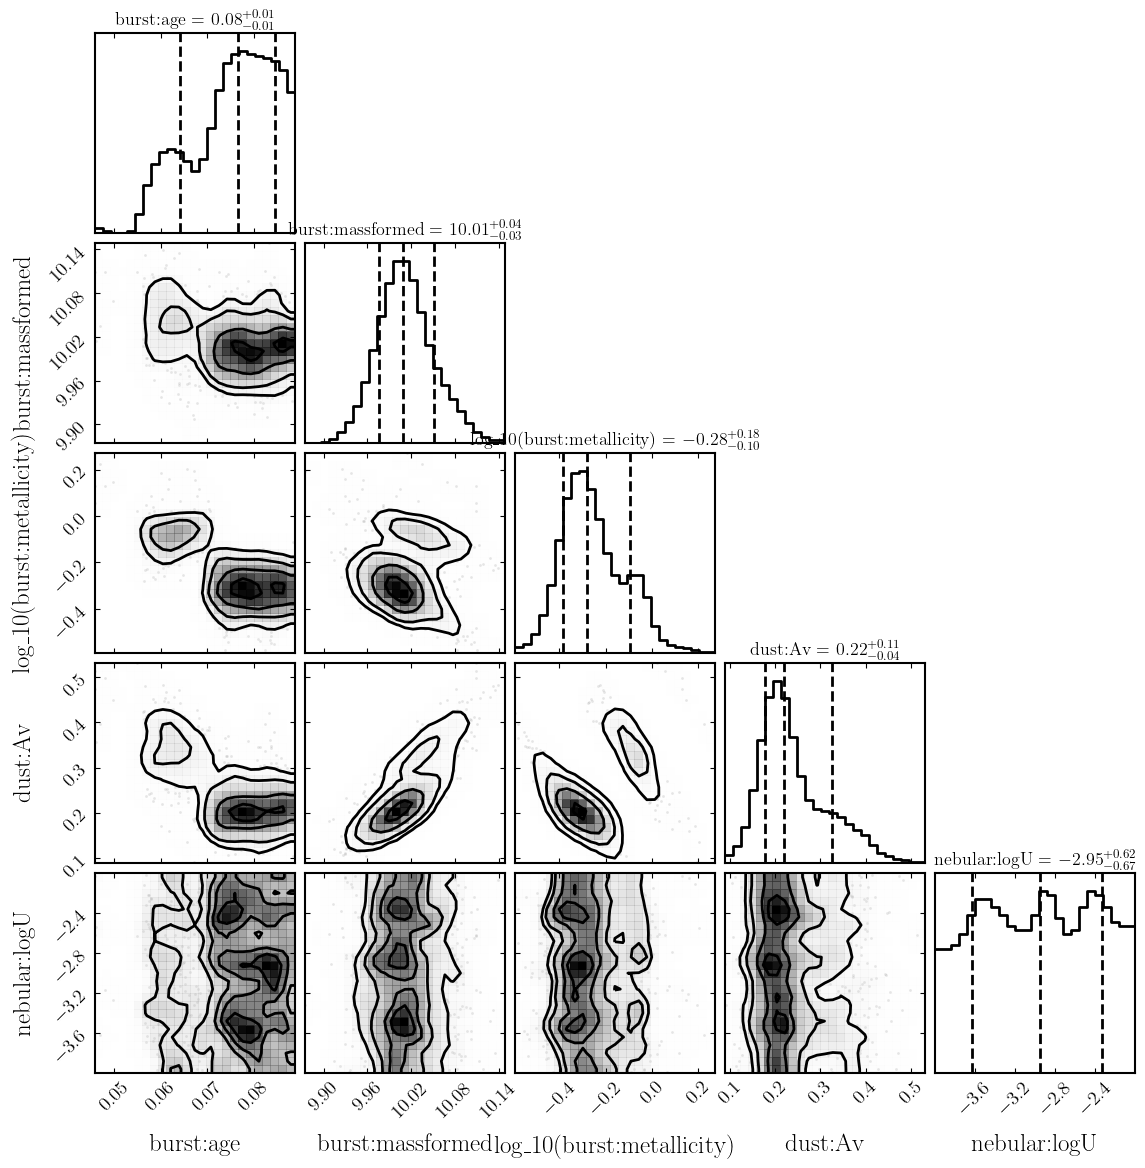


Plotting results for age 0.090 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-20 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

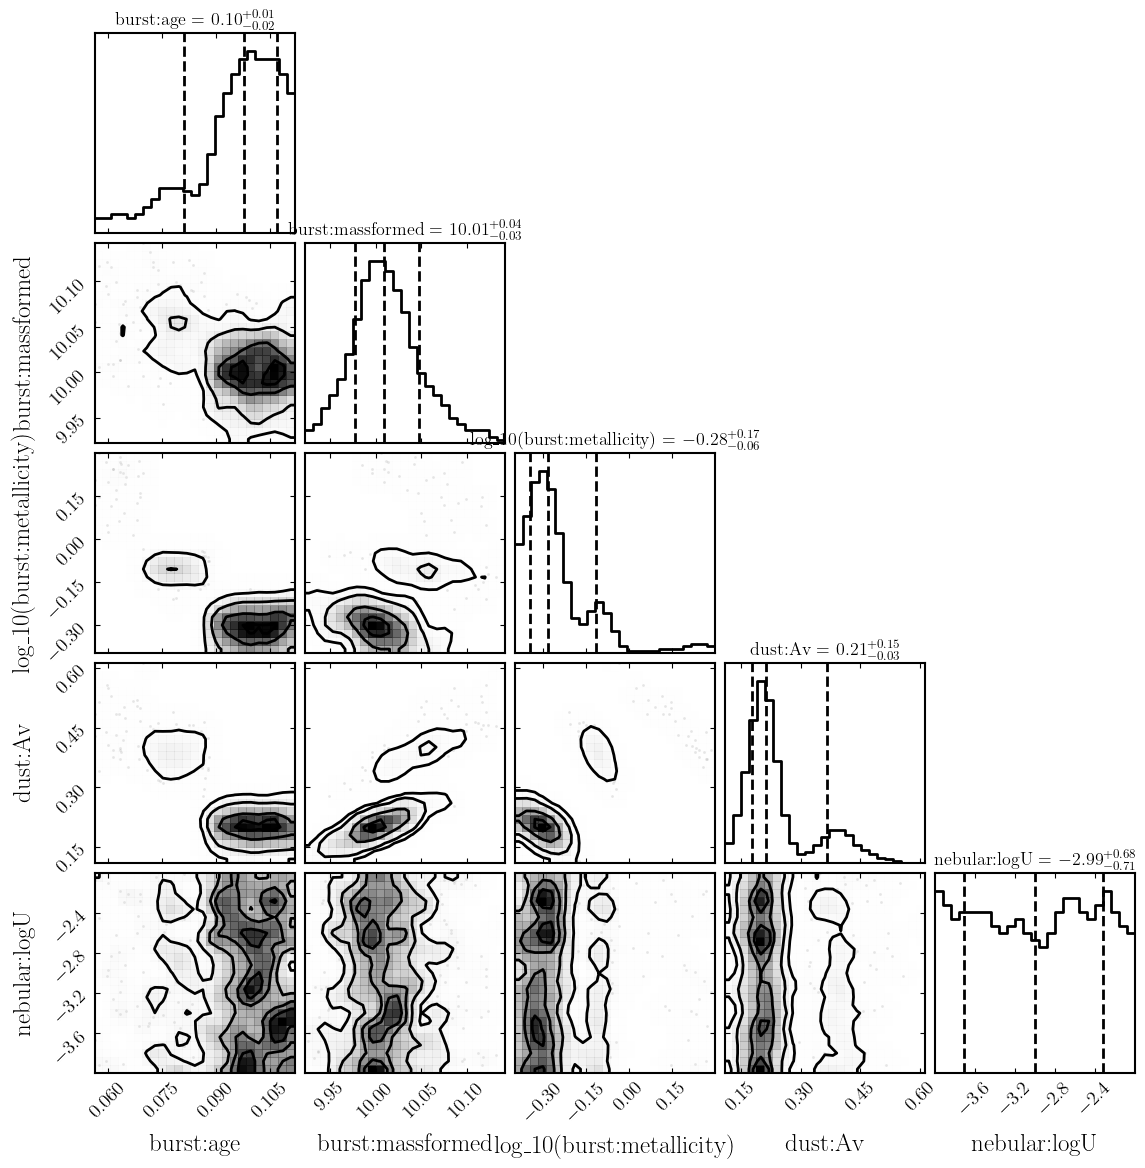


Plotting results for age 0.100 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-20 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

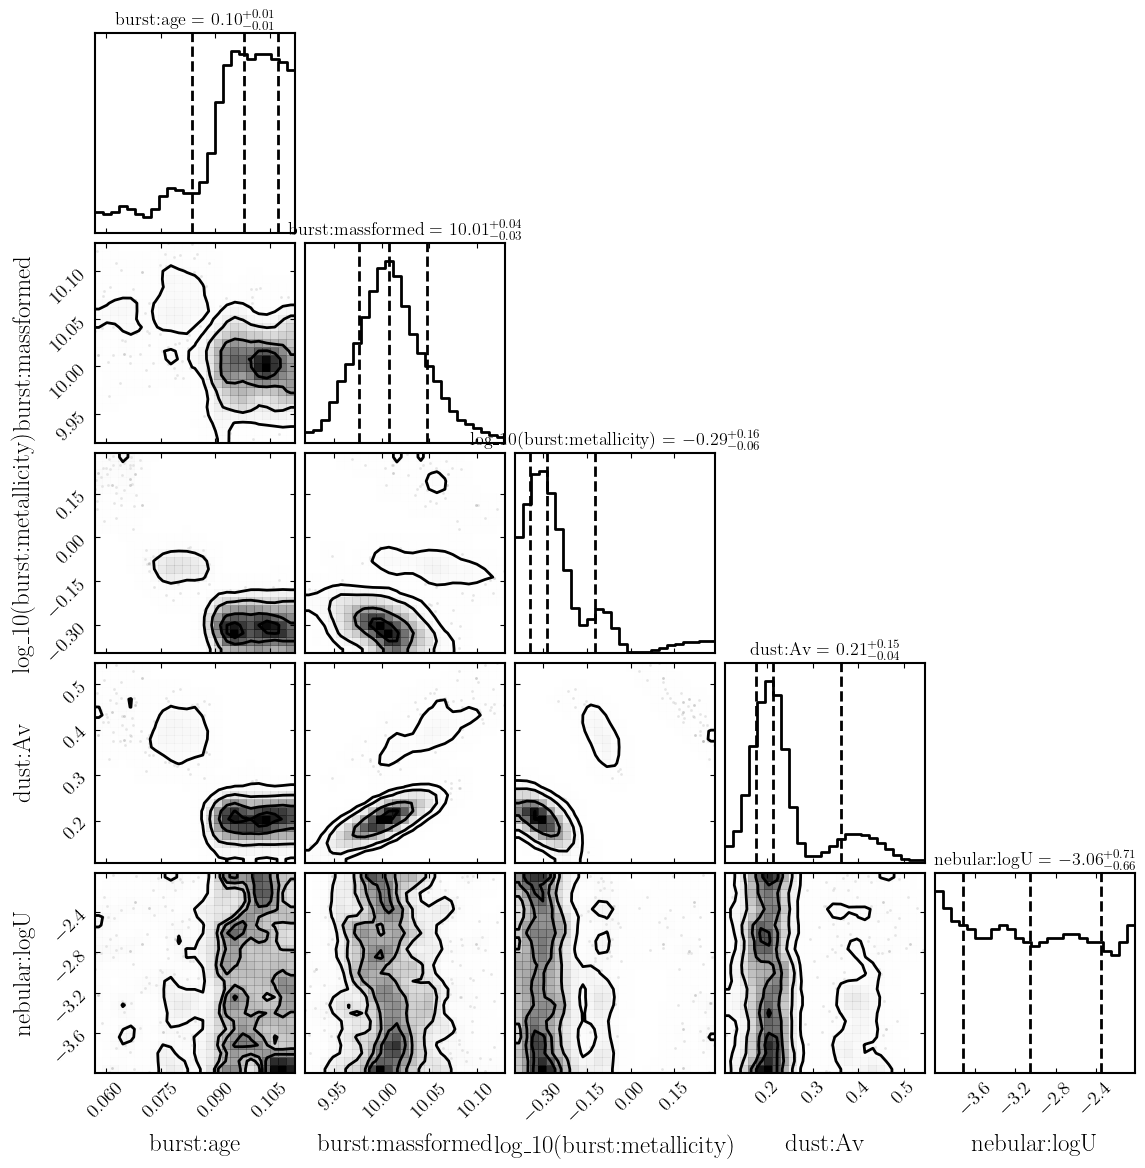


Plotting results for age 0.200 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-21 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

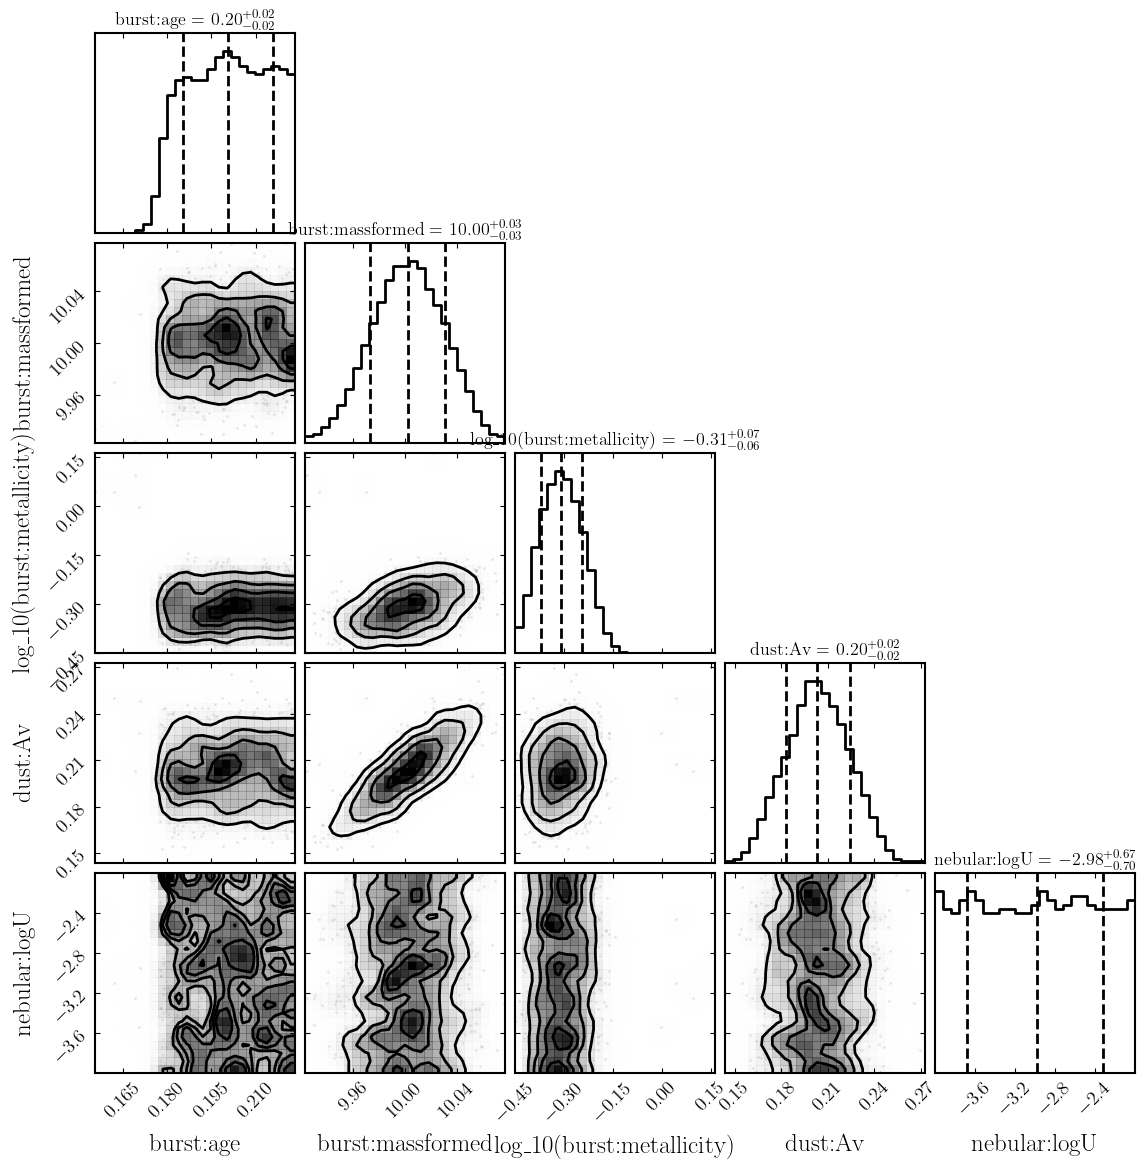


Plotting results for age 0.300 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-21 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

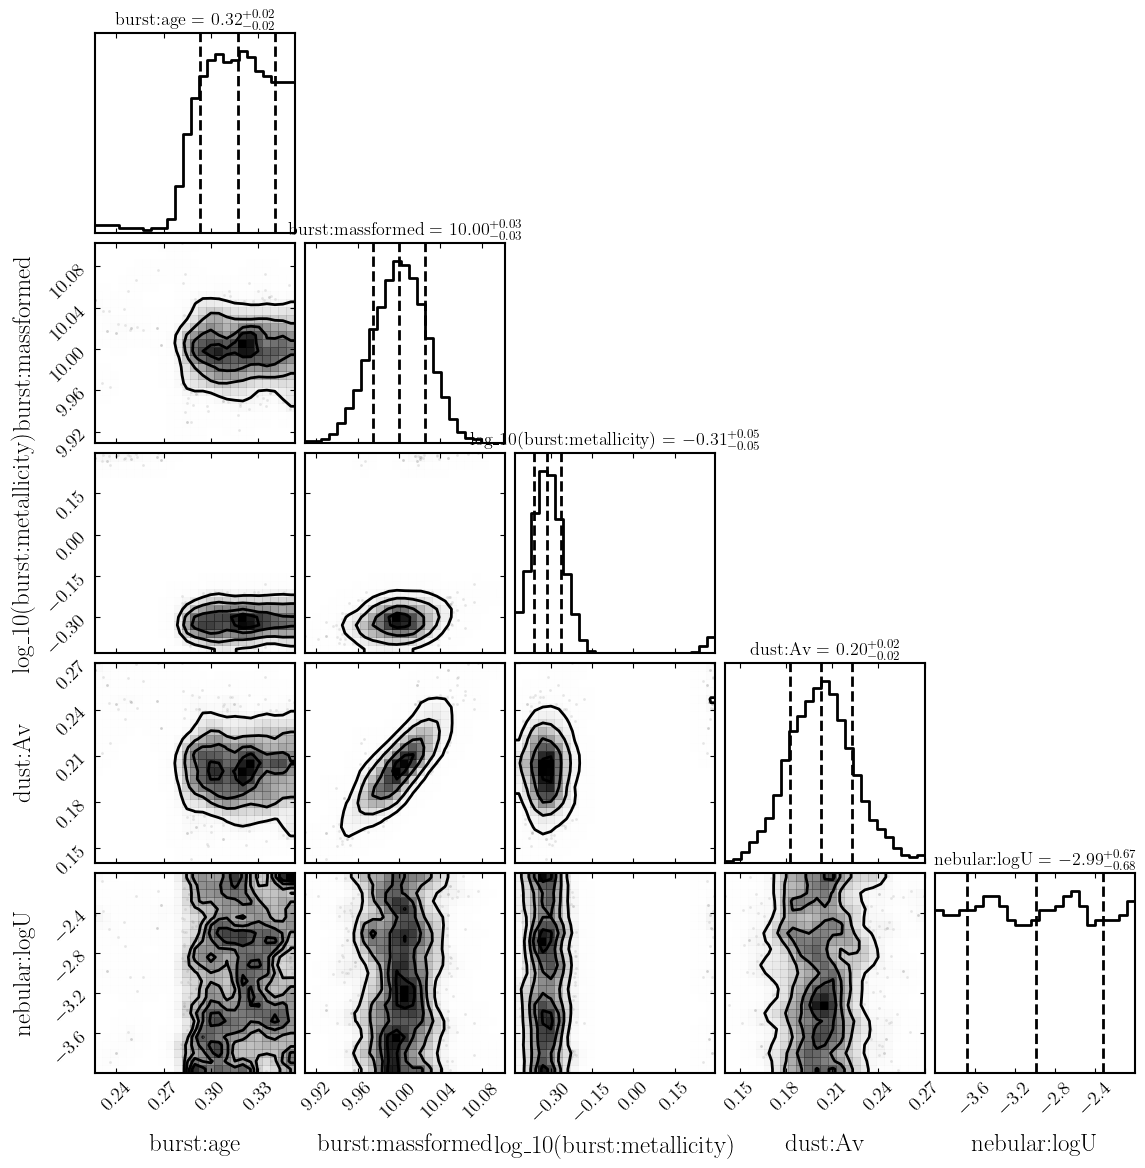


Plotting results for age 0.400 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-21 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

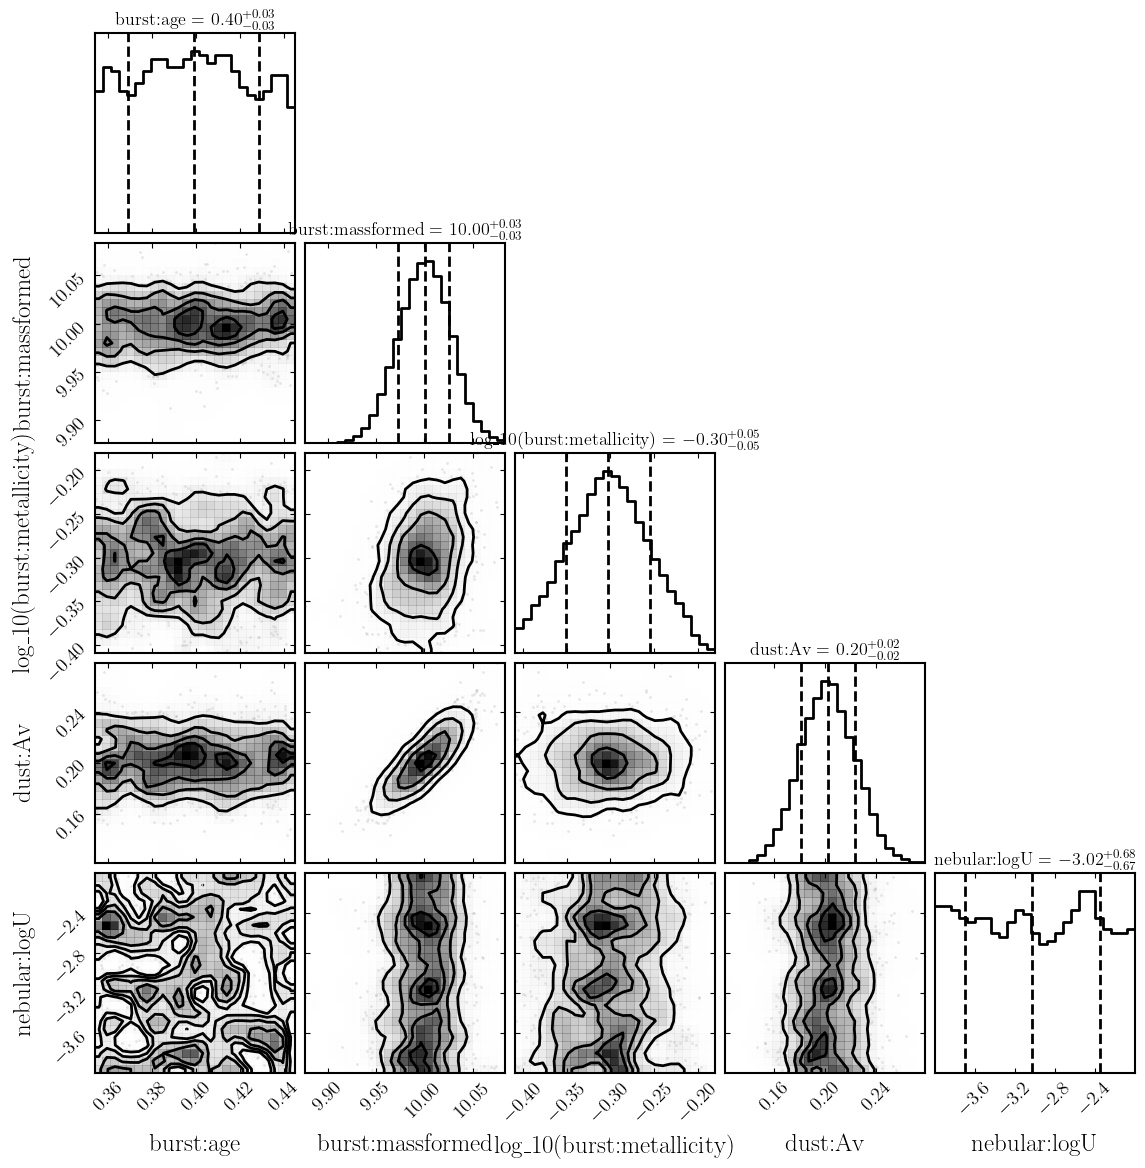


Plotting results for age 0.500 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-21 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

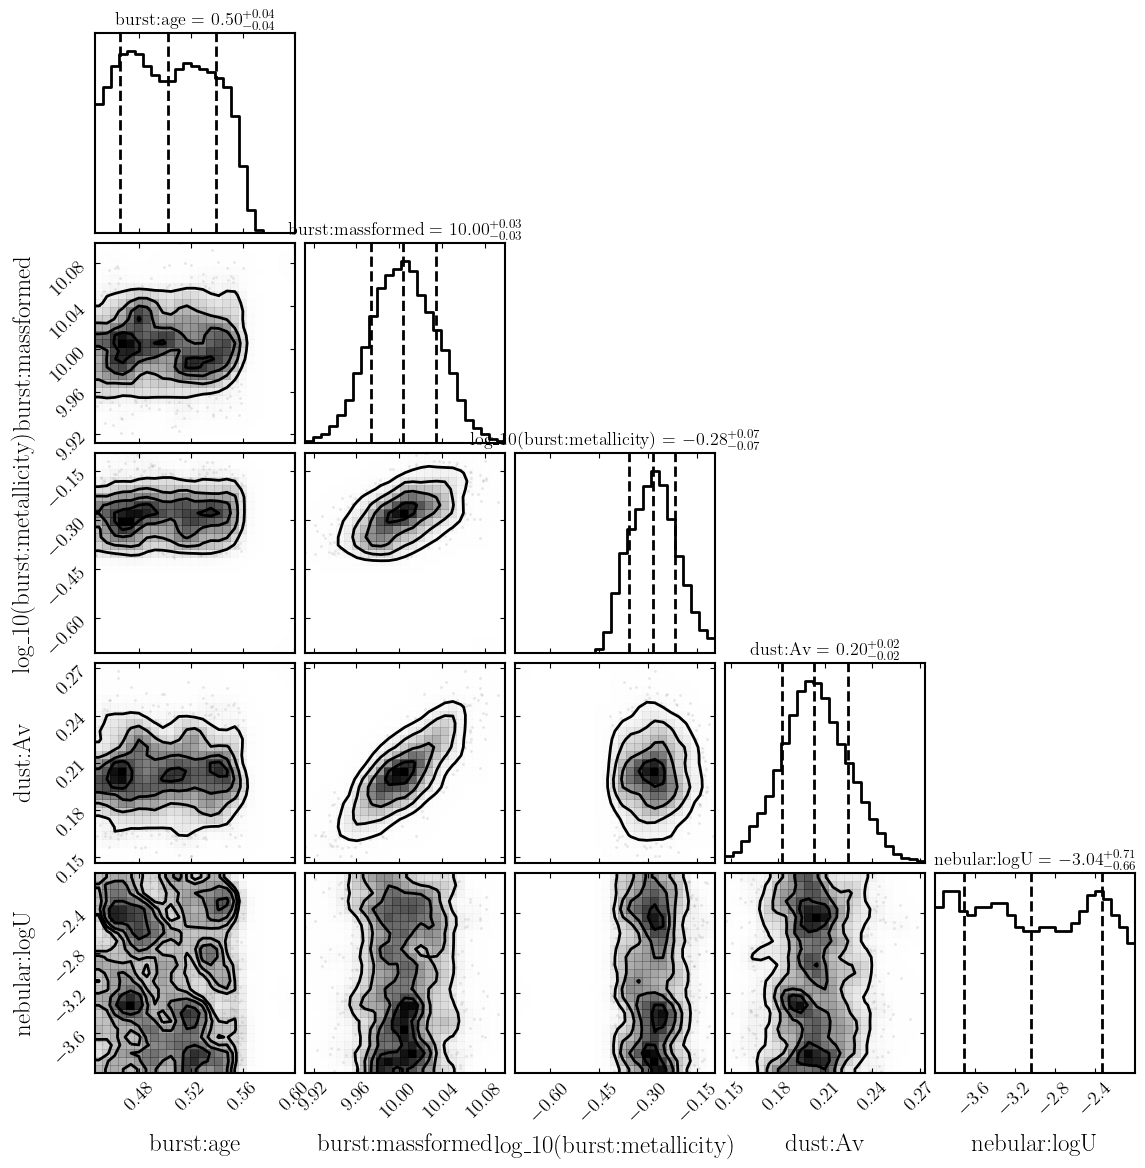


Plotting results for age 0.600 Gyr


RuntimeError: latex was not able to process the following string:
b'f_lambda / 10^-21 erg s^-1 cm^-2 A^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional inform

<Figure size 1200x400 with 1 Axes>

RuntimeError: latex was not able to process the following string:
b'SFR / M_sol yr^-1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.1) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(D:\Code\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(D:\Code\tex/latex/base\size10.clo)) (D:\Code\tex/latex/type1cm\type1cm.sty)
(D:\Code\tex/latex/cm-super\type1ec.sty (D:\Code\tex/latex/base\t1cmr.fd))
(D:\Code\tex/latex/base\inputenc.sty) (D:\Code\tex/latex/geometry\geometry.sty
(D:\Code\tex/latex/graphics\keyval.sty) (D:\Code\tex/generic/iftex\ifvtex.sty
(D:\Code\tex/generic/iftex\iftex.sty)) (D:\Code\tex/latex/geometry\geometry.cfg
)) (D:\Code\tex/latex/amsmath\amsmath.sty
For additional information on amsmath, us

<Figure size 1200x400 with 2 Axes>

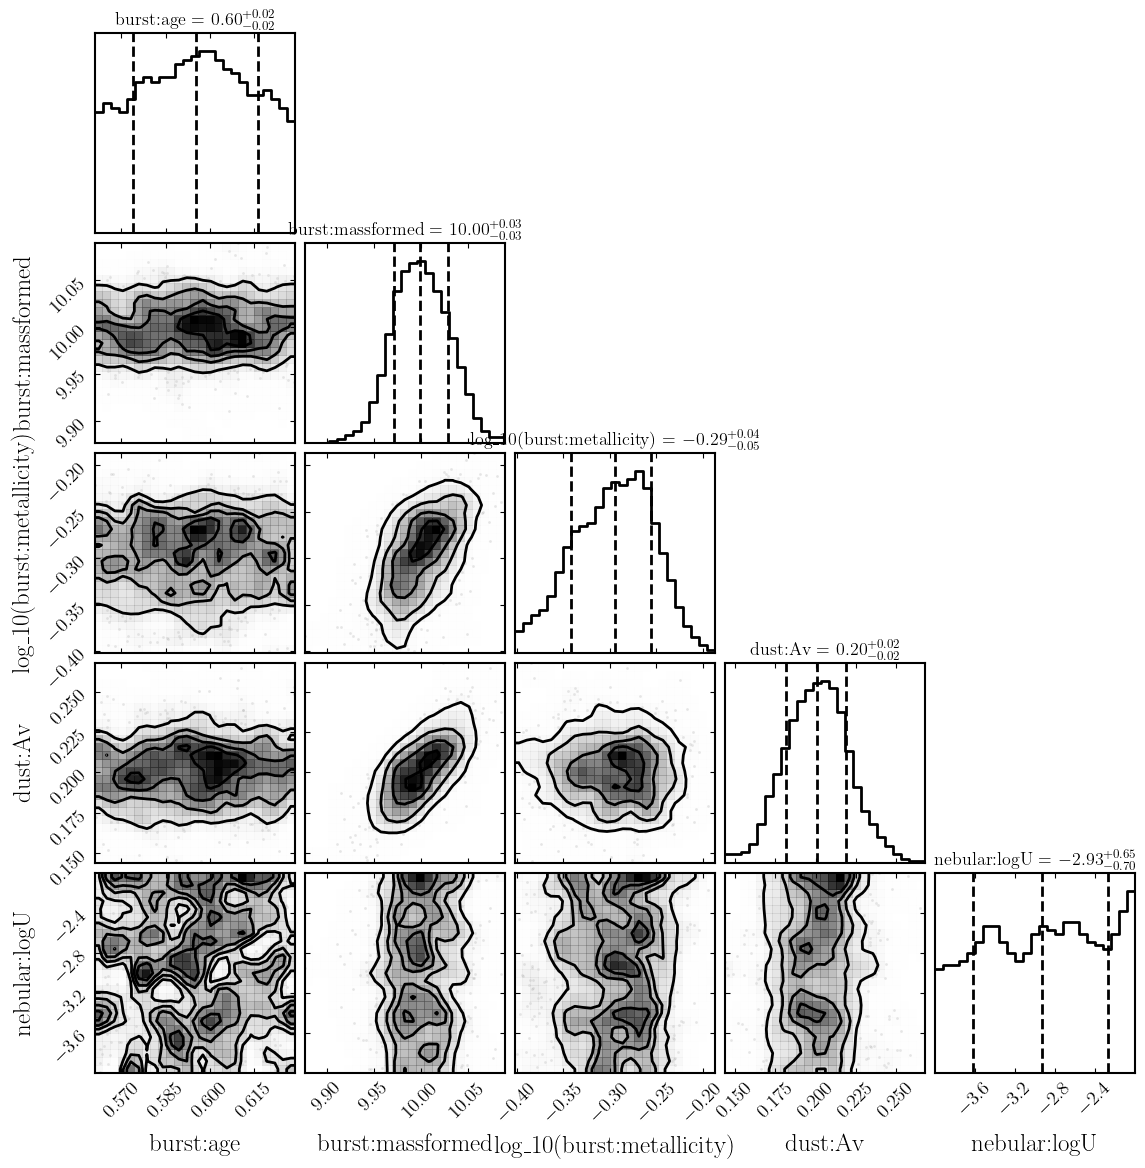

In [12]:
for i, fit in enumerate(fits):

    print(f"\nPlotting results for age {years[i]:.3f} Gyr")

    fit.plot_spectrum_posterior(show=True, save=False)

    fit.plot_sfh_posterior(show=True, save=False)

    fit.plot_corner(show=True, save=False)